In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/wadi-data/WADI_14days_new.csv
/kaggle/input/wadi-data/WADI_attackdataLABLE.csv


Loading WADI dataset...
Dataset loaded successfully! Shape: (172803, 131)
Columns: ['Row ', 'Date ', 'Time', '1_AIT_001_PV', '1_AIT_002_PV', '1_AIT_003_PV', '1_AIT_004_PV', '1_AIT_005_PV', '1_FIT_001_PV', '1_LS_001_AL', '1_LS_002_AL', '1_LT_001_PV', '1_MV_001_STATUS', '1_MV_002_STATUS', '1_MV_003_STATUS', '1_MV_004_STATUS', '1_P_001_STATUS', '1_P_002_STATUS', '1_P_003_STATUS', '1_P_004_STATUS', '1_P_005_STATUS', '1_P_006_STATUS', '2_DPIT_001_PV', '2_FIC_101_CO', '2_FIC_101_PV', '2_FIC_101_SP', '2_FIC_201_CO', '2_FIC_201_PV', '2_FIC_201_SP', '2_FIC_301_CO', '2_FIC_301_PV', '2_FIC_301_SP', '2_FIC_401_CO', '2_FIC_401_PV', '2_FIC_401_SP', '2_FIC_501_CO', '2_FIC_501_PV', '2_FIC_501_SP', '2_FIC_601_CO', '2_FIC_601_PV', '2_FIC_601_SP', '2_FIT_001_PV', '2_FIT_002_PV', '2_FIT_003_PV', '2_FQ_101_PV', '2_FQ_201_PV', '2_FQ_301_PV', '2_FQ_401_PV', '2_FQ_501_PV', '2_FQ_601_PV', '2_LS_001_AL', '2_LS_002_AL', '2_LS_101_AH', '2_LS_101_AL', '2_LS_201_AH', '2_LS_201_AL', '2_LS_301_AH', '2_LS_301_AL', '2_

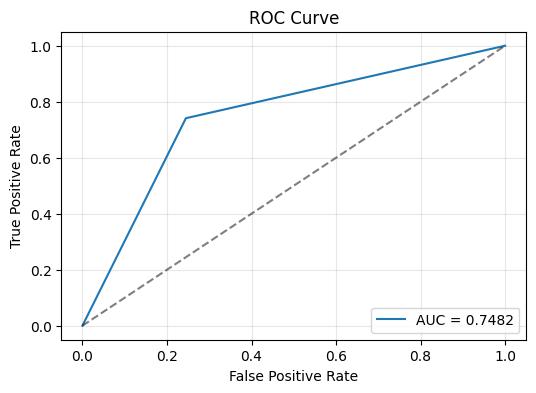




Generating visualizations (window-based)...


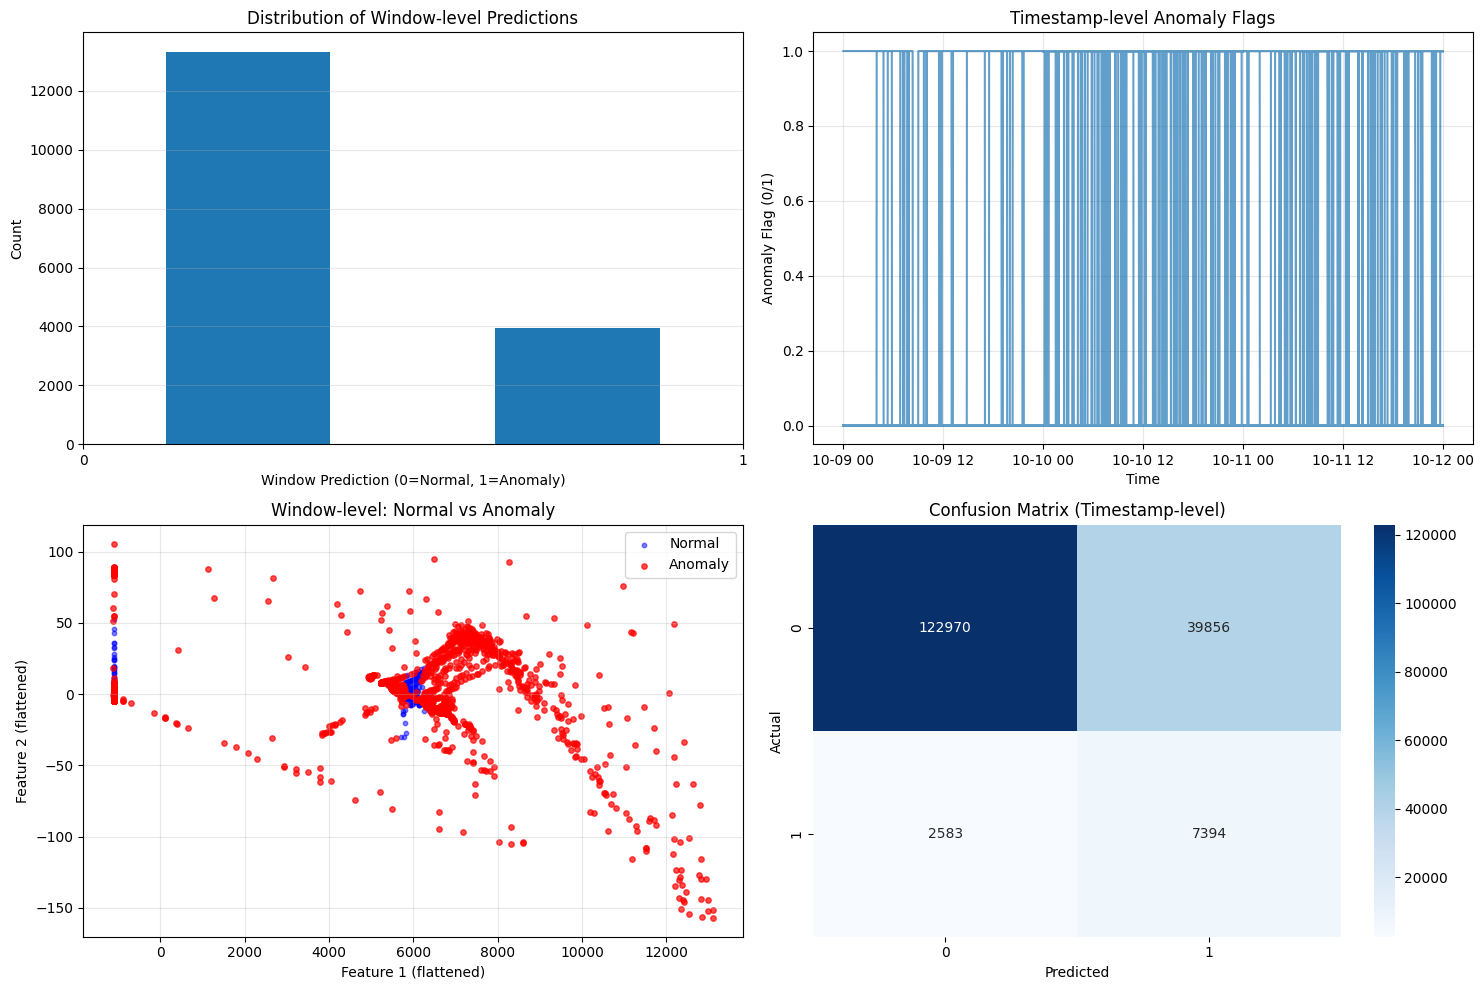

Anomaly Detection Summary (timestamps):
total_timestamps: 172803
anomalies_detected: 47250
anomaly_ratio: 0.2734327529035954
anomaly_indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 19

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve
)
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer
import warnings
warnings.filterwarnings('ignore')

class WADIAnomalyDetector:
    def __init__(self, contamination=0.1, kernel='rbf', gamma='scale', nu=0.2):
        """
        Initialize WADI Anomaly Detector with One-Class SVM

        - contamination: Expected proportion of outliers (for evaluation)
        - kernel: Kernel type for SVM ('rbf', 'linear', 'poly', 'sigmoid')
        - gamma: Kernel coefficient
        - nu: Upper bound on fraction of training errors and lower bound of support vectors
        """
        self.contamination = contamination
        self.kernel = kernel
        self.gamma = gamma
        self.nu = nu

        # Những thuộc tính sẽ được gán khi load/xử lý dữ liệu
        self.data = None
        self.features = None          # DataFrame ban đầu (có thể chứa cả string)
        self.y_true = None            # Nhãn gốc (1=no-attack, -1=attack)
        self.features_numeric = None  # Toàn bộ cột đã ép sang số (NaN nếu lỗi)
        self.features_scaled = None
        self.features_final = None    # Nếu có PCA, đây là data sau PCA; nếu không thì = features_scaled
        self.time_data = None         # Nếu có cột thời gian
        self.time_column = None

        # Các thuộc tính để sliding-window SVM
        self.window_size = None
        self.step_size = None
        self.window_indices = None    # Danh sách (start, end) cho mỗi window
        self.svm = None
        self.window_preds = None      # Nhãn window (1=anomaly, 0=normal)
        self.timestamp_pred = None    # Nhãn timestamp cuối cùng (1=anomaly, 0=normal)

        # Nếu muốn vẫn giữ phương thức detect cũ, giữ nguyên:
        self.model = None
        self.X_train = None
        self.X_test = None
        self.anomaly_scores = None
        self.anomaly_labels = None


    def load_data(self, file_path, target_column=None, date_column='Date ', time_column='Time'):
        """
        Load WADI dataset từ CSV và ghép cột Date + Time thành datetime index.

        - file_path: đường dẫn tới file CSV
        - target_column: tên cột nhãn (nếu có)
        - date_column: tên cột chứa ngày (thường là 'Date ' có dấu cách cuối)
        - time_column: tên cột chứa giờ (thường là 'Time')
        """
        print("Loading WADI dataset...")
        try:
            # Đọc CSV với header=1 (bỏ row 0 có header không chính xác)
            try:
                self.data = pd.read_csv(file_path, header=1, encoding='utf-8')
            except UnicodeDecodeError:
                self.data = pd.read_csv(file_path, header=1, encoding='latin-1')

            print(f"Dataset loaded successfully! Shape: {self.data.shape}")
            print(f"Columns: {list(self.data.columns)}")
            print("\nFirst few rows of the dataset:")
            print(self.data.head())
            print("\nData types of columns:")
            print(self.data.dtypes)

            # 1. Ghép Date + Time thành DateTime nếu cả hai cột đều tồn tại
            if date_column in self.data.columns and time_column in self.data.columns:
                # Loại bỏ khoảng trắng thừa nếu có
                self.data[date_column] = self.data[date_column].astype(str).str.strip()
                self.data[time_column] = self.data[time_column].astype(str).str.strip()

                # Tạo cột tạm string để parse
                self.data['DateTime_str'] = self.data[date_column] + ' ' + self.data[time_column]

                # Chuyển sang datetime (định dạng WADI: 'm/d/yy HH:MM.S')
                self.data['DateTime'] = pd.to_datetime(
                    self.data['DateTime_str'],
                    format='%m/%d/%y %H:%M.%f',
                    errors='coerce'
                )

                # Nếu một số giá trị không parse được, pandas sẽ trả NaT
                num_na = self.data['DateTime'].isna().sum()
                if num_na > 0:
                    print(f"Warning: có {num_na} giá trị DateTime bị NaT (không parse được).")

                # Đặt DateTime làm index
                self.data = self.data.set_index('DateTime', drop=False)
                print("Set 'DateTime' as index.")

                # Xóa cột tạm
                self.data.drop(columns=['DateTime_str', '2B_AIT_002_PV'], inplace=True)
                self.time_data = self.data.index
                self.time_column = 'DateTime'
            else:
                print(f"Time column '{time_column}' or date column '{date_column}' not found, using default index.")
                self.time_data = None
                self.time_column = None

            # 2. Tách nhãn (nếu có) và features
            self.target_column = target_column
            if target_column and target_column in self.data.columns:
                self.y_true = self.data[target_column].astype(int)
                # Drop cột target và cột date/time gốc khỏi features
                drop_cols = [target_column]
                if date_column in self.data.columns:
                    drop_cols.append(date_column)
                if time_column in self.data.columns:
                    drop_cols.append(time_column)
                self.features = self.data.drop(columns=drop_cols, errors='ignore')
            else:
                # Không có target, chỉ drop date/time gốc (nếu có)
                drop_cols = []
                if date_column in self.data.columns:
                    drop_cols.append(date_column)
                if time_column in self.data.columns:
                    drop_cols.append(time_column)
                self.features = self.data.drop(columns=drop_cols, errors='ignore')
                self.y_true = None

            self.feature_names = list(self.features.columns)

            print(f"\nDataset Overview:")
            print(f"Number of features: {len(self.feature_names)}")
            print(f"Number of samples: {len(self.features)}")
            print("Missing values per column (10 đầu):")
            missing_counts = self.features.isnull().sum()
            print(missing_counts[missing_counts > 0].head(10))

            return self.data

        except Exception as e:
            print(f"Error loading dataset: {e}")
            return None


    def preprocess_data(self, method='median', use_pca=True, n_components=50):
        """
        Preprocess the WADI dataset

        Steps:
        1. Ép mọi cột sang numeric (non-numeric sẽ thành NaN).
        2. Impute missing values (median/mean/knn).
        3. Loại bỏ cột constant (nunique <= 1).
        4. Scale với RobustScaler.
        5. Nếu use_pca=True, áp dụng PCA (n_components không vượt quá số cột hiện có).
        """
        if self.features is None:
            raise ValueError("Features are not loaded. Please call load_data() first.")

        # 1. Chuyển tất cả cột sang numeric, non-numeric → NaN
        self.features_numeric = self.features.apply(lambda col: pd.to_numeric(col, errors='coerce'))

        # Nếu có cột toàn NaN (toàn non-numeric), drop chúng
        all_nan_cols = [c for c in self.features_numeric.columns if self.features_numeric[c].isna().all()]
        if all_nan_cols:
            self.features_numeric = self.features_numeric.drop(columns=all_nan_cols)
            print(f"Dropped {len(all_nan_cols)} column(s) that were entirely NaN after to_numeric.")

        # Sau khi drop, nếu hoàn toàn không còn cột nào thì báo lỗi
        if self.features_numeric.shape[1] == 0:
            raise ValueError("Không có cột numeric nào để tiền xử lý (all columns are non-numeric).")

        # 2. Impute missing values
        if method in ['median', 'mean']:
            self.imputer = SimpleImputer(strategy=method)
        elif method == 'knn':
            self.imputer = KNNImputer(n_neighbors=5)
        else:
            raise ValueError(f"Unsupported imputation method: {method}")

        imputed_array = self.imputer.fit_transform(self.features_numeric)
        numeric_df = pd.DataFrame(imputed_array,
                                  columns=self.features_numeric.columns,
                                  index=self.features_numeric.index)

        # 3. Loại bỏ cột constant (nunique <= 1)
        constant_cols = [col for col in numeric_df.columns if numeric_df[col].nunique() <= 1]
        if constant_cols:
            numeric_df = numeric_df.drop(columns=constant_cols)
            print(f"Removed {len(constant_cols)} constant column(s).")

        # 4. Scale với RobustScaler
        self.scaler = RobustScaler()
        scaled_array = self.scaler.fit_transform(numeric_df)
        self.features_scaled = pd.DataFrame(scaled_array,
                                            columns=numeric_df.columns,
                                            index=numeric_df.index)

        # 5. Áp dụng PCA nếu use_pca=True
        if use_pca:
            n_comp = min(n_components, self.features_scaled.shape[1])
            self.pca = PCA(n_components=n_comp, random_state=42)
            pca_array = self.pca.fit_transform(self.features_scaled)
            pc_names = [f'PC{i+1}' for i in range(n_comp)]
            self.features_final = pd.DataFrame(pca_array,
                                               columns=pc_names,
                                               index=self.features_scaled.index)
            print(f"Applied PCA: {self.features_scaled.shape[1]} → {n_comp} components")
            print("Explained variance ratio (first 5):", self.pca.explained_variance_ratio_[:5])
        else:
            self.features_final = self.features_scaled.copy()

        print(f"Final feature matrix shape: {self.features_final.shape}")
        return self.features_final


    def create_windows_flat(self, window_size, step_size):
        """
        Tạo các cửa sổ (window) từ features_final.
        Mỗi window là [window_size x n_features], sau đó flatten thành 1 vector 1D.

        Returns:
        - windows: np.array shape = (n_windows, window_size * n_features)
        - indices: list of tuples (start, end) cho mỗi window
        """
        arr = self.features_final.values  # (n_timestamps, n_features)
        n_timestamps, n_features = arr.shape

        windows = []
        indices = []
        for start in range(0, n_timestamps - window_size + 1, step_size):
            end = start + window_size
            flat = arr[start:end].flatten()  # Kích thước: window_size * n_features
            windows.append(flat)
            indices.append((start, end))
        windows = np.array(windows)
        return windows, indices


    def train_oneclass_svm_windows(self, window_size=30, step_size=5):
        """
        Train One-Class SVM dựa trên các window của chuỗi thời gian.

        - window_size: số timestamp trong 1 window
        - step_size: bước nhảy giữa các window
        """
        if self.features_final is None:
            raise ValueError("Features have not been preprocessed. Please call preprocess_data() first.")

        # Tạo window flattened
        self.window_size = window_size
        self.step_size = step_size
        windows, indices = self.create_windows_flat(window_size, step_size)
        self.window_indices = indices  # lưu lại (start, end) cho mapping sau này

        # Nếu có nhãn, chọn chỉ các window hoàn toàn normal (không chứa timestamp bị attack)
        if self.y_true is not None:
            # Biến y_true thành mảng binary: 1 nếu attack, 0 nếu normal
            y_arr = self.y_true.values
            y_binary = (y_arr == -1).astype(int)

            # Tính label cho mỗi window: nếu bất kỳ timestamp nào trong window =1, gán window=1 (anomaly)
            window_labels = np.array([
                int(np.any(y_binary[start:end] == 1))
                for (start, end) in indices
            ])

            normal_mask = (window_labels == 0)
            normal_windows = windows[normal_mask]
            print(f"Training on {normal_windows.shape[0]} normal windows (window_size={window_size}, step={step_size}).")

            if normal_windows.shape[0] == 0:
                raise ValueError("Không có window hoàn toàn bình thường để huấn luyện. Kiểm tra nhãn lại.")

            # Train One-Class SVM
            self.svm = OneClassSVM(kernel=self.kernel, gamma=self.gamma, nu=self.nu)
            self.svm.fit(normal_windows)

            # Dự đoán trên tất cả window (bao gồm cả normal + attack)
            raw_preds = self.svm.predict(windows)  # +1=normal, -1=anomaly
            self.window_preds = (raw_preds == -1).astype(int)  # 1=anomaly, 0=normal
        else:
            # Nếu không có nhãn, train trên tất cả windows và predict tất cả
            self.svm = OneClassSVM(kernel=self.kernel, gamma=self.gamma, nu=self.nu)
            self.svm.fit(windows)
            raw_preds = self.svm.predict(windows)
            self.window_preds = (raw_preds == -1).astype(int)
            print(f"Trained SVM trên {windows.shape[0]} windows (không nhãn).")

        return self.svm


    def map_window_preds_to_timestamps(self):
        """
        Map kết quả window-level (self.window_preds) về timestamp-level (self.timestamp_pred).
        Nếu bất kỳ window nào chứa timestamp t bị đánh dấu anomaly (1),
        thì timestamp t cũng được gán nhãn anomaly (1).
        """
        if self.window_preds is None or self.window_indices is None:
            raise ValueError("Bạn phải gọi train_oneclass_svm_windows(...) trước.")

        n_timestamps = self.features_final.shape[0]
        flags = np.zeros(n_timestamps, dtype=int)

        for idx, (start, end) in enumerate(self.window_indices):
            if self.window_preds[idx] == 1:  # Nếu window idx là anomaly
                flags[start:end] = 1

        self.timestamp_pred = flags  # 1=anomaly, 0=normal
        return self.timestamp_pred


    def evaluate_performance_svm_windows(self):
        """
        Nếu có y_true, đánh giá performance giữa y_true (timestamp-level) và timestamp_pred.
        """
        if self.y_true is None:
            print("No ground truth labels for evaluation.")
            return None
        if self.timestamp_pred is None:
            raise ValueError("Bạn phải gọi map_window_preds_to_timestamps() trước.")

        # Chuyển y_true sang binary: 1 nếu attack, 0 nếu normal (timestamp-level)
        y_true_bin = (self.y_true.values == -1).astype(int)
        y_pred = self.timestamp_pred

        # Đảm bảo độ dài khớp
        assert len(y_true_bin) == len(y_pred), "Length mismatch between y_true và y_pred."

        print(">> One-Class SVM (window-based) Evaluation <<")
        evaluate_binary(y_true_bin, y_pred)

        return {
            'y_true': y_true_bin,
            'y_pred': y_pred
        }


    def visualize_results(self, figsize=(15, 10)):
        """
        Visualize kết quả One-Class SVM window-based.
        """
        if self.window_preds is None or self.timestamp_pred is None:
            raise ValueError("Bạn phải gọi map_window_preds_to_timestamps() trước khi visualize_results().")

        print("\nGenerating visualizations (window-based)...")
        fig, axes = plt.subplots(2, 2, figsize=figsize)

        # 1. Histogram của window-level preds
        axes[0, 0].hist(self.window_preds, bins=2, rwidth=0.5)
        axes[0, 0].set_xticks([0, 1])
        axes[0, 0].set_xlabel('Window Prediction (0=Normal, 1=Anomaly)')
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].set_title('Distribution of Window-level Predictions')
        axes[0, 0].grid(True, alpha=0.3)

        # 2. Time series của timestamp-level preds
        if self.time_data is not None:
            time_idx = self.time_data
        else:
            time_idx = np.arange(len(self.timestamp_pred))

        axes[0, 1].plot(time_idx, self.timestamp_pred, alpha=0.7, label='Pred Anomaly Flag')
        axes[0, 1].set_xlabel('Time' if self.time_data is not None else 'Timestamp Index')
        axes[0, 1].set_ylabel('Anomaly Flag (0/1)')
        axes[0, 1].set_title('Timestamp-level Anomaly Flags')
        axes[0, 1].grid(True, alpha=0.3)

        # 3. PCA scatter plot (nếu có ít nhất 2 PC)
        if self.pca is not None and self.features_final.shape[1] >= 2:
            # Chỉ dùng 2 chiều đầu để minh họa, thực chất không thật sự "PCA" window
            # Chúng ta vẫn plot flattened window trên 2 trục đầu
            windows, _ = self.create_windows_flat(self.window_size, self.step_size)
            pc1 = windows[:, 0]
            pc2 = windows[:, 1] if windows.shape[1] > 1 else windows[:, 0]
            anomaly_mask = (self.window_preds == 1)
            normal_mask = (self.window_preds == 0)
            axes[1, 0].scatter(pc1[normal_mask], pc2[normal_mask], c='blue', alpha=0.5, s=10, label='Normal')
            axes[1, 0].scatter(pc1[anomaly_mask], pc2[anomaly_mask], c='red', alpha=0.7, s=15, label='Anomaly')
            axes[1, 0].set_xlabel('Feature 1 (flattened)')
            axes[1, 0].set_ylabel('Feature 2 (flattened)')
            axes[1, 0].set_title('Window-level: Normal vs Anomaly')
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)
        else:
            axes[1, 0].axis('off')
            axes[1, 0].text(0.5, 0.5, 'PCA not applied or <2 features', ha='center', va='center')

        # 4. Confusion matrix heatmap timestamp-level (nếu có nhãn)
        if self.y_true is not None:
            y_true_bin = (self.y_true.values == -1).astype(int)
            cm = confusion_matrix(y_true_bin, self.timestamp_pred)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
            axes[1, 1].set_title('Confusion Matrix (Timestamp-level)')
            axes[1, 1].set_xlabel('Predicted')
            axes[1, 1].set_ylabel('Actual')
        else:
            axes[1, 1].axis('off')
            axes[1, 1].text(0.5, 0.5, 'No true labels available', ha='center', va='center')

        plt.tight_layout()
        plt.show()


    def get_anomaly_summary(self):
        """
        Get a summary of anomalies ở timestamp-level.
        """
        if self.timestamp_pred is None:
            raise ValueError("Bạn phải gọi map_window_preds_to_timestamps() trước khi get_anomaly_summary().")

        flags = self.timestamp_pred
        anomaly_idx = np.where(flags == 1)[0]
        summary = {
            'total_timestamps': len(flags),
            'anomalies_detected': int(len(anomaly_idx)),
            'anomaly_ratio': float(len(anomaly_idx) / len(flags)),
            'anomaly_indices': anomaly_idx.tolist()
        }
        return summary


def evaluate_binary(y_true, y_pred):
    """
    Evaluate binary anomaly detection results.
    - y_true: 1D array-like của true labels (1 = anomaly, 0 = normal)
    - y_pred: 1D array-like của predicted labels (1 = anomaly, 0 = normal)
    """
    print("===== Classification Report =====")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print("===== Confusion Matrix =====")
    print(cm)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        roc_auc = roc_auc_score(y_true, y_pred)
    except ValueError:
        roc_auc = None

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC AUC:   {roc_auc:.4f}")
        # Vẽ ROC Curve
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0,1],[0,1], 'k--', alpha=0.5)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.show()
    print("\n")


# ================ Example usage ================
if __name__ == "__main__":
    detector = WADIAnomalyDetector(
        contamination=0.1,
        kernel='rbf',
        gamma='scale',
        nu=0.2
    )

    # 1. Load dữ liệu
    data = detector.load_data(
        '/kaggle/input/wadi-data/WADI_attackdataLABLE.csv',
        target_column='Attack LABLE (1:No Attack, -1:Attack)',
        date_column='Date ',
        time_column='Time'
    )

    if data is not None:
        # 2. Tiền xử lý: ép sang số, impute median, PCA xuống 50 dim
        features = detector.preprocess_data(method='knn', use_pca=True, n_components=50)

        # 3. Train One-Class SVM trên sliding window
        WINDOW_SIZE = 30
        STEP_SIZE = 10
        detector.train_oneclass_svm_windows(window_size=WINDOW_SIZE, step_size=STEP_SIZE)

        # 4. Map window-level → timestamp-level
        detector.map_window_preds_to_timestamps()

        # 5. Đánh giá hiệu năng (timestamp-level) nếu có nhãn
        detector.evaluate_performance_svm_windows()

        # 6. Visualize kết quả (window-based)
        detector.visualize_results()

        # 7. Tóm tắt anomalies (timestamp-level)
        summary = detector.get_anomaly_summary()
        print("Anomaly Detection Summary (timestamps):")
        for k, v in summary.items():
            print(f"{k}: {v}")
        print("Detection completed successfully!")
    else:
        print("Failed to load dataset. Please kiểm tra đường dẫn và format file.")
